# Apartment Price Prediction - Canton of Zurich

Iterative modeling process for predicting monthly rental prices.

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
import pickle

## Data Loading & Cleaning

In [2]:
df = pd.read_csv("apartments_data.csv", sep=",", encoding="utf-8")
df = df.dropna()
df = df.drop_duplicates()
print(f"Dataset shape after cleaning: {df.shape}")
df.head()

Dataset shape after cleaning: (2344, 45)


,Unnamed: 0,bfs_number,rooms,area,price,postalcode,address,town,description_raw,bfs_name,...,Kreis 10,Kreis 4,Kreis 1,Kreis 9,Kreis 5,Kreis 7,Kreis 3,Kreis 2,Kreis 8,zurich_city
0,0,261,4.5,148,4180,8050,"Schaffhauserstrasse 363, 8050 Zürich",Zürich,««Renovierte 4.5-Zimmerwohnung an zentraler La...,Zürich,...,0,0,0,0,0,0,0,0,0,1
1,1,261,2.0,122,3190,8050,"Max Bill Platz 5, 8050 Zürich",Zürich,«Modernes Wohnen im Zentrum von Oerlikon»,Zürich,...,0,0,0,0,0,0,0,0,0,1
2,2,261,3.5,78,2780,8050,"Regensbergstrasse 30, 8050 Zürich",Zürich,«Wohnen am Puls von Zürich»,Zürich,...,0,0,0,0,0,0,0,0,0,1
3,3,261,3.5,69,3750,8050,"Dörflistrasse 112, 8050 Zürich",Zürich,"«Trendy Oerlikon 3.5 Room w/ Balcony, 1min to ...",Zürich,...,0,0,0,0,0,0,0,0,0,1
4,4,261,3.5,74,2390,8050,"Schaffhauserstrasse 445, 8050 Zürich",Zürich,«Helle und zentrale Wohnung in Zürich-Oerlikon»,Zürich,...,0,0,0,0,0,0,0,0,0,1


In [3]:
df.columns.tolist()

['Unnamed: 0',
 'bfs_number',
 'rooms',
 'area',
 'price',
 'postalcode',
 'address',
 'town',
 'description_raw',
 'bfs_name',
 'pop',
 'pop_dens',
 'frg_pct',
 'emp',
 'tax_income',
 'lat',
 'lon',
 'x',
 'y',
 'room_per_m2',
 'price_per_m2',
 'luxurious',
 'temporary',
 'furnished',
 'area_cat',
 'area_cat_ecoded',
 '(LOFT)',
 '(POOL)',
 '(ATTIKA)',
 '(EXKLUSIV)',
 '(SEESICHT)',
 '(LUXURIÖS)',
 'Kreis 6',
 'Kreis 11',
 'Kreis 12',
 'Kreis 10',
 'Kreis 4',
 'Kreis 1',
 'Kreis 9',
 'Kreis 5',
 'Kreis 7',
 'Kreis 3',
 'Kreis 2',
 'Kreis 8',
 'zurich_city']

## Feature Engineering: New Feature - Distance to Zurich HB

Compute the haversine distance (km) from each apartment's coordinates to Zurich Hauptbahnhof (lat=47.3769, lon=8.5417). This feature was **not used in any prior exercise** and captures how far an apartment is from the city center.

In [4]:
ZURICH_HB_LAT = 47.3769
ZURICH_HB_LON = 8.5417


def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c


df["distance_to_zurich_hb"] = haversine(df["lat"], df["lon"], ZURICH_HB_LAT, ZURICH_HB_LON)

if "room_per_m2" not in df.columns:
    df["room_per_m2"] = df["area"] / df["rooms"]

target = "price"
y = df[target]

print(f"distance_to_zurich_hb range: {df['distance_to_zurich_hb'].min():.1f} - {df['distance_to_zurich_hb'].max():.1f} km")
print(f"room_per_m2 range: {df['room_per_m2'].min():.1f} - {df['room_per_m2'].max():.1f}")

distance_to_zurich_hb range: 0.2 - 101.5 km
room_per_m2 range: 10.0 - 179.3


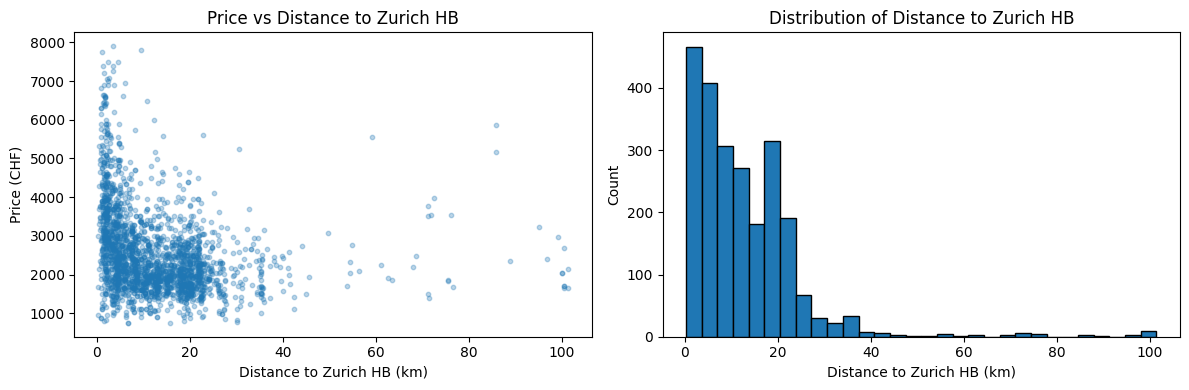

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["distance_to_zurich_hb"], df["price"], alpha=0.3, s=10)
axes[0].set_xlabel("Distance to Zurich HB (km)")
axes[0].set_ylabel("Price (CHF)")
axes[0].set_title("Price vs Distance to Zurich HB")

axes[1].hist(df["distance_to_zurich_hb"], bins=30, edgecolor="black")
axes[1].set_xlabel("Distance to Zurich HB (km)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Distance to Zurich HB")

plt.tight_layout()
plt.show()

---
## Iteration 1 - Baseline

**Objective:** Establish baseline performance using the original municipality features.

**Preprocessing:**
- Removed missing values (dropna)
- Removed duplicates (drop_duplicates)

**Features (7):** rooms, area, pop, pop_dens, frg_pct, emp, tax_income

**Models:**
- Linear Regression (default hyperparameters)
- Random Forest (n_estimators=100, random_state=42)

**Validation:** 5-Fold Cross-Validation with R2 and RMSE

In [6]:
baseline_features = ["rooms", "area", "pop", "pop_dens", "frg_pct", "emp", "tax_income"]
X1 = df[baseline_features]

models_iter1 = {
    "Linear Regression": LinearRegression(),
    "Random Forest (n=100)": RandomForestRegressor(n_estimators=100, random_state=42),
}

results_iter1 = []
for name, model in models_iter1.items():
    r2 = cross_val_score(model, X1, y, cv=5, scoring="r2")
    rmse = -cross_val_score(model, X1, y, cv=5, scoring="neg_root_mean_squared_error")
    results_iter1.append({
        "Model": name,
        "CV Mean R2": round(r2.mean(), 4),
        "CV Std R2": round(r2.std(), 4),
        "CV Mean RMSE": round(rmse.mean(), 0),
        "CV Std RMSE": round(rmse.std(), 0),
    })

df_results1 = pd.DataFrame(results_iter1)
df_results1

,Model,CV Mean R2,CV Std R2,CV Mean RMSE,CV Std RMSE
0,Linear Regression,0.5394,0.0878,678.0,208.0
1,Random Forest (n=100),0.5364,0.0511,674.0,169.0


**Diagnosis:** Both models show moderate performance (~0.54 R2). Random Forest does not improve over Linear Regression with only 7 features, indicating the baseline features have limited predictive power. High RMSE variance suggests the models struggle with certain subgroups (e.g. Zurich city apartments with wide price ranges).

---
## Iteration 2 - Enhanced Features + Tuned Models

**Objective:** Improve performance by adding the new distance feature, additional categorical features, and tuning model hyperparameters.

**Changes compared to Iteration 1:**
- Added new feature: `distance_to_zurich_hb` (haversine distance to Zurich main station)
- Added features: `room_per_m2`, `furnished`, `zurich_city`
- Used 3 models with tuned hyperparameters

**Preprocessing:**
- Same as iteration 1
- Computed haversine distance from apartment lat/lon to Zurich HB

**Features (11):** rooms, area, pop, pop_dens, frg_pct, emp, tax_income, distance_to_zurich_hb, room_per_m2, furnished, zurich_city

**Models:**
- Ridge Regression (alpha=1.0)
- Random Forest (n_estimators=300, max_depth=20, min_samples_leaf=5)
- Gradient Boosting (n_estimators=300, max_depth=5, learning_rate=0.1)

**Validation:** 5-Fold Cross-Validation with R2 and RMSE

In [7]:
enhanced_features = [
    "rooms", "area", "pop", "pop_dens", "frg_pct", "emp", "tax_income",
    "distance_to_zurich_hb", "room_per_m2", "furnished", "zurich_city",
]
X2 = df[enhanced_features]

models_iter2 = {
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Random Forest (n=300, depth=20)": RandomForestRegressor(
        n_estimators=300, max_depth=20, min_samples_leaf=5, random_state=42
    ),
    "Gradient Boosting (n=300, depth=5, lr=0.1)": GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42
    ),
}

best_r2 = -np.inf
best_model_name = ""
best_model = None

results_iter2 = []
for name, model in models_iter2.items():
    r2 = cross_val_score(model, X2, y, cv=5, scoring="r2")
    rmse = -cross_val_score(model, X2, y, cv=5, scoring="neg_root_mean_squared_error")
    results_iter2.append({
        "Model": name,
        "CV Mean R2": round(r2.mean(), 4),
        "CV Std R2": round(r2.std(), 4),
        "CV Mean RMSE": round(rmse.mean(), 0),
        "CV Std RMSE": round(rmse.std(), 0),
    })
    if r2.mean() > best_r2:
        best_r2 = r2.mean()
        best_model_name = name
        best_model = model

df_results2 = pd.DataFrame(results_iter2)
df_results2

,Model,CV Mean R2,CV Std R2,CV Mean RMSE,CV Std RMSE
0,Ridge (alpha=1.0),0.5378,0.0855,679.0,206.0
1,"Random Forest (n=300, depth=20)",0.5986,0.0687,628.0,173.0
2,"Gradient Boosting (n=300, depth=5, lr=0.1)",0.6136,0.0503,613.0,144.0


**Diagnosis:** Gradient Boosting achieves the best R2 of 0.6136, an improvement of +0.077 over the baseline. The additional features (especially distance_to_zurich_hb and zurich_city) capture location-based price variation. RMSE std decreased from 169 to 144, meaning more consistent predictions across folds. Ridge Regression does not benefit much from the new features since the relationships are non-linear.

---
## Summary

| Iteration | Objective | Models | Best CV R2 | Best CV RMSE | Change |
|-----------|-----------|--------|------------|--------------|--------|
| 1 | Baseline with 7 features | Linear Regression, Random Forest | 0.5394 | 674 | - |
| 2 | +4 features, tuned models | Ridge, Random Forest, Gradient Boosting | 0.6136 | 613 | +0.074 R2 |

---
## Feature Importance (Best Model)

Best model: Gradient Boosting (n=300, depth=5, lr=0.1)


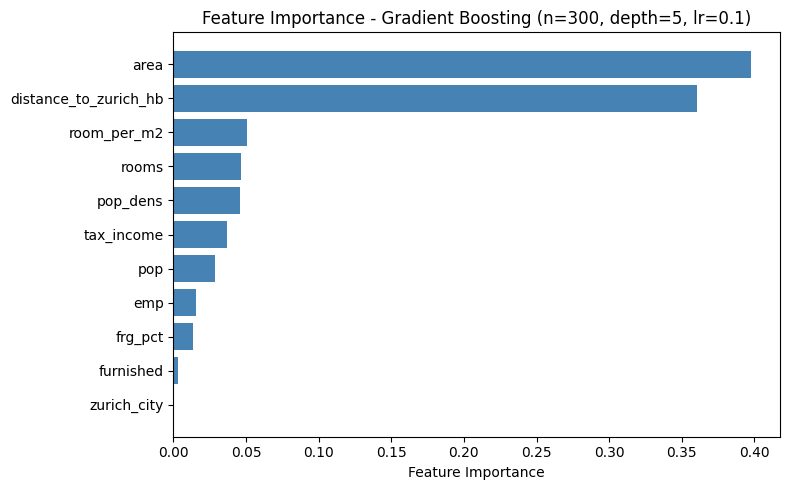

In [8]:
print(f"Best model: {best_model_name}")

best_model.fit(X2, y)

importances = best_model.feature_importances_
df_fi = pd.DataFrame({"feature": enhanced_features, "importance": importances})
df_fi = df_fi.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_fi["feature"], df_fi["importance"], color="steelblue")
plt.xlabel("Feature Importance")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

---
## Residual Analysis

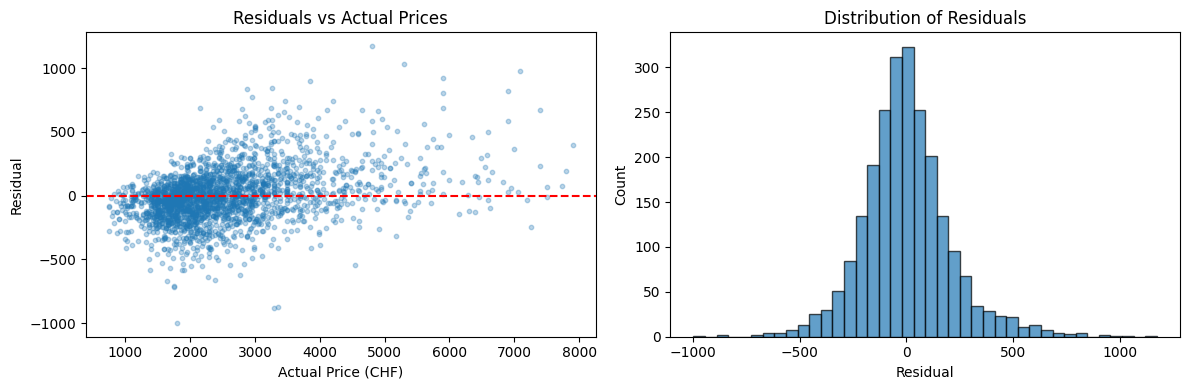

Mean residual: 0.0
Std residual: 209.8


In [9]:
y_pred = best_model.predict(X2)
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color="r", linestyle="--")
axes[0].set_xlabel("Actual Price (CHF)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Actual Prices")

axes[1].hist(residuals, bins=40, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.1f}")
print(f"Std residual: {residuals.std():.1f}")

---
## Save Model & Municipality Lookup

In [10]:
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("Saved model.pkl")

with open("features.txt", "w") as f:
    f.write("\n".join(enhanced_features))
print("Saved features.txt")

municipality_lookup = (
    df.groupby("bfs_number")
    .agg({
        "bfs_name": "first",
        "pop": "first",
        "pop_dens": "first",
        "frg_pct": "first",
        "emp": "first",
        "tax_income": "first",
        "lat": "mean",
        "lon": "mean",
        "zurich_city": "first",
    })
    .reset_index()
)
municipality_lookup.to_csv("municipality_lookup.csv", index=False)
print(f"Saved municipality_lookup.csv ({len(municipality_lookup)} municipalities)")

Saved model.pkl
Saved features.txt
Saved municipality_lookup.csv (111 municipalities)


---
## Test Prediction

In [11]:
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

muni = pd.read_csv("municipality_lookup.csv")
zurich = muni[muni["bfs_name"] == "Zürich"].iloc[0]

test_input = pd.DataFrame([{
    "rooms": 3.5,
    "area": 80,
    "pop": zurich["pop"],
    "pop_dens": zurich["pop_dens"],
    "frg_pct": zurich["frg_pct"],
    "emp": zurich["emp"],
    "tax_income": zurich["tax_income"],
    "distance_to_zurich_hb": haversine(zurich["lat"], zurich["lon"], ZURICH_HB_LAT, ZURICH_HB_LON),
    "room_per_m2": 80 / 3.5,
    "furnished": 0,
    "zurich_city": 1,
}])

prediction = loaded_model.predict(test_input[enhanced_features])[0]
print(f"3.5 rooms, 80m2 in Zürich -> CHF {prediction:,.0f} / month")

3.5 rooms, 80m2 in Zürich -> CHF 3,436 / month
